(ch:ml-regression)=
# 회귀 프로젝트

머신러닝 프로젝트는 데이터를 이용하여 예측 모델을 훈련시키고, 훈련된 모델을 실전에 투입되었을 때의 성능을 평가하는 과정이다. 
이번 장에서는 파머 펭귄 데이터셋과 함께 회귀 프로젝트를 진행하는 과정을 소개한다.

**기본 설정**

머신러닝 프로젝트에 필요한 기본 라이브러리를 불러온다. 

- `numpy`: 어레이 기반 데이터 처리
- `pandas`: 데이터프레임 기반 데이터 처리
- `matplotlib.pyplot`: 데이터 시각화
- `seaborn`: 통계 기반 데이터 시각화
- `sklearn`: 머신러닝 모델 훈련


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

데이터프레임 내 부동소수점을 소수점 이하 6자리까지만 출력하도록 지정한다.

In [2]:
pd.set_option('display.precision', 6)

**데이터 저장소**

In [3]:
data_url = 'https://raw.githubusercontent.com/codingalzi/code-workout-datasci/refs/heads/master/data/'

## 머신러닝 프로젝트 흐름

머신러닝 프로젝트는 보통 다음 순서로 진행된다.

| 단계 | 내용 |
|:---:|---|
| 1 | **문제 정의**<br>해결하려는 문제와 목표를 명확히 정한다. |
| 2 | **데이터 적재**<br>데이터를 불러온다. |
| 3 | **데이터 구조 확인**<br>데이터의 행과 열, 자료형, 결측치 등을 확인한다. |
| 4 | **데이터 정리 및 분할**<br>필요한 결측치를 처리하고 데이터를 훈련셋과 테스트셋으로 나눈다. |
| 5 | **탐색적 데이터 분석**<br>훈련셋의 분포와 관계를 살펴 데이터의 특징을 파악한다. |
| 6 | **모델 훈련**<br>훈련셋을 사용하여 머신러닝 모델을 학습시킨다. |
| 7 | **훈련 결과 해석**<br>훈련 결과를 해석하고 성능 개선 방향을 정한다. |
| 8 | **일반화 성능 평가**<br>훈련된 모델의 일반화 성능을 평가한다. |

실제 프로젝트에서는 전처리, 특성 공학, 모델 선택, 하이퍼파라미터 튜닝 등 훨씬 복잡한 과정을 수행한다. 하지만 기본 뼈대는 위 흐름에서 크게 벗어나지 않는다.

## 1단계: 문제 정의

**데이터셋**

[선형 상관관계](#ch:linear-correlation)와 [데이터 시각화](#ch:data-visualization)에서 살펴 본 파머 데이터셋을 활용한다.
파머 펭귄 데이터셋은 남극 파머 군도<font size='2'>Palmer Archipelago</font>의 세 섬에서 관찰된 Chinstrap, Gentoo, Adelie 세 종(species)의 펭귄에 대한 자료이며,
[Gorman, Williams, Fraser(2014)](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0090081)의 연구에서 공개되었다.

<div align="center">
    <img src="https://github.com/codingalzi/code-workout-datasci/blob/master/images/palmer-penguins.png?raw=true" width="500px">
</div>

<p><div style="text-align: center"><a href="https://allisonhorst.github.io/palmerpenguins/">Artwork by @allison_horst</a></div></p>

데이터셋에는 총 344 마리 펭귄의 신체 측정값과 함께 펭귄 종, 서식지, 성별 정보가 특성으로 포함되어 있다.

| 특성 | 의미 |
| :--- | :--- |
| `species` | 펭귄 종 (Adelie, Chinstrap, Gentoo) |
| `island` | 관찰된 섬 (Torgersen, Biscoe, Dream) |
| `bill_length_mm` | 부리 길이 (mm) |
| `bill_depth_mm` | 부리 두께 (mm) |
| `flipper_length_mm` | 날개 길이 (mm) |
| `body_mass_g` | 몸무게 (g) |
| `sex` | 성별 (Male, Female) |

펭귄 부리의 길이와 두께는 아래 이미지에서처럼 측정되었다.

<div align="center">
    <img src="https://github.com/codingalzi/code-workout-datasci/blob/master/images/palmer-bill_depth.png?raw=true" width="500px">
</div>

<p><div style="text-align: center"><a href="https://allisonhorst.github.io/palmerpenguins/">Artwork by @allison_horst</a></div></p>

**해결해야 할 문제**

펭귄의 부리의 길이와 두께, 날개의 길이 세 종류의 정보를 이용하여 펭귄의 몸무게를 예측하는 머신러닝 모델을 훈련시킨다. 

예측값인 몸무게는 부동소수점으로 구성된 연속형 수치이며,
따라서  이 문제는 **회귀 문제**에 해당한다.

## 2단계: 데이터 적재

파머 데이터셋은 다양한 데이터 저장소에서 다운로드할 수 있지만 여기서는 `seaborn` 라이브러리에서 제공하는 데이터셋을 불러온다.

In [5]:
penguins = sns.load_dataset('penguins')
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## 3단계: 데이터 구조 파악

먼저 데이터의 크기, 열 이름, 결측치, 기본 통계량을 확인한다. 이 단계의 목적은 모델을 바로 만드는 것이 아니라, 데이터가 어떤 모양인지 감을 잡는 것이다.

데이터의 행과 열 개수를 확인한다. 머신러닝 프로젝트를 시작할 때 데이터 규모를 파악하면, 이후 훈련셋과 테스트셋의 크기를 이해하기 쉽다.

In [9]:
penguins.shape

(344, 8)

각 열의 자료형과 결측치가 아닌 값의 개수를 확인한다. 수치형 열과 범주형 열을 구분하고, 결측치가 있는 열을 찾기 위해 필요한 단계이다.

In [10]:
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 27.6 KB


열마다 결측치가 몇 개 있는지 계산한다. 결측치는 모델 훈련 과정에서 오류를 일으킬 수 있으므로, 전처리 전에 반드시 확인해야 한다.

In [11]:
penguins.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

열 이름을 목록으로 확인한다. 이 단계에서는 데이터의 형태와 결측치 여부까지만 살펴보고, 값의 분포와 관계에 대한 상세한 탐색은 테스트셋을 분리한 뒤 훈련셋으로 수행한다.

In [12]:
penguins.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'],
      dtype='str')

이번 회귀 문제에서 사용할 입력 특성과 타깃을 정한다. `species`는 모델의 입력으로 사용하지 않지만, 훈련셋과 테스트셋에 세 종이 비슷한 비율로 포함되도록 나누기 위한 층화 기준으로 사용한다.

In [13]:
regression_features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
]
target = "body_mass_g"
required_columns = ["species", *regression_features, target]

required_columns

['species',
 'bill_length_mm',
 'bill_depth_mm',
 'flipper_length_mm',
 'body_mass_g']

결측치는 모델 훈련에 사용하는 열과 층화 기준인 `species`에 대해서만 처리한다. `sex`와 `island`처럼 이번 모델에 사용하지 않는 열의 결측치 때문에 활용 가능한 관측값까지 제거할 필요는 없다. 이 장에서는 흐름을 간단히 보여 주기 위해 필요한 열에 결측치가 있는 행만 제거한다.

모델링과 층화 분할에 필요한 열을 기준으로 결측치가 포함된 행을 제거하여 분석용 데이터프레임을 만든다. 실제 프로젝트에서는 결측치가 생긴 원인을 살펴보고 대체 방법도 비교할 수 있다.

In [14]:
penguins_clean = penguins.dropna(subset=required_columns).copy()
penguins_clean.shape

(342, 8)

## 4단계: 데이터 분할

데이터를 자세히 탐색하고 모델을 훈련하기 전에, 분석용 데이터를 **훈련셋**과 **테스트셋**으로 나눈다. 훈련셋은 데이터의 패턴을 탐색하고 모델을 학습시키는 데 사용한다. 테스트셋은 층화 분할이 의도대로 수행되었는지 종별 비율만 확인하고, 특성과 타깃의 관계는 마지막 성능 평가 전까지 탐색하지 않는다. 이렇게 남겨 둔 테스트셋으로 처음 보는 데이터에 대한 성능을 확인한다.

이 데이터에서는 `species`에 따라 신체 측정값과 몸무게의 분포가 다를 수 있으므로, 세 종의 비율이 훈련셋과 테스트셋에 비슷하게 유지되도록 층화 샘플링을 사용한다.

분석용 데이터를 `species` 기준으로 층화하여 훈련셋과 테스트셋으로 나눈다. 이후의 탐색적 데이터 분석과 모델 훈련에는 `penguins_train`만 사용한다.

In [15]:
penguins_train, penguins_test = train_test_split(
    penguins_clean,
    test_size=0.2,
    random_state=42,
    stratify=penguins_clean["species"],
)

pd.DataFrame(
    {
        "dataset": ["Full data", "Training set", "Test set"],
        "rows": [len(penguins_clean), len(penguins_train), len(penguins_test)],
    }
)

,dataset,rows
0,Full data,342
1,Training set,273
2,Test set,69


**종별 비율**

층화 분할의 결과를 확인하기 위해 전체 분석용 데이터와 훈련셋, 테스트셋의 종별 비율을 비교한다. 이 확인은 분할 방식이 의도대로 작동했는지 점검하는 과정이며, 테스트셋의 몸무게나 특성 관계를 탐색하는 것은 아니다.

In [16]:
species_ratio = pd.DataFrame({
    "Full data": penguins_clean["species"].value_counts(normalize=True),
    "Training set": penguins_train["species"].value_counts(normalize=True),
    "Test set": penguins_test["species"].value_counts(normalize=True),
}).sort_index()

species_ratio

,Full data,Training set,Test set
species,,,
Adelie,0.441520,0.443223,0.434783
Chinstrap,0.198830,0.197802,0.202899
Gentoo,0.359649,0.358974,0.362319


## 5단계: 탐색적 데이터 분석

탐색적 데이터 분석(EDA)은 모델을 훈련하기 전에 데이터의 패턴을 살펴보는 과정이다. 이제부터는 테스트셋을 보지 않고 **훈련셋만** 이용하여 다음 질문에 답해 본다.

1. 훈련셋은 어떤 종과 섬의 관측값으로 구성되어 있는가?
2. 예측하려는 몸무게는 어떤 범위와 분포를 가지는가?
3. 어떤 신체 측정값이 몸무게 예측에 도움이 될까?

먼저 종별 관측 수와 섬별 종 분포를 확인한다. `island`는 이번 모델의 입력으로 사용하지 않지만, 관측된 펭귄의 구성을 이해하기 위한 배경 정보로 살펴본다.

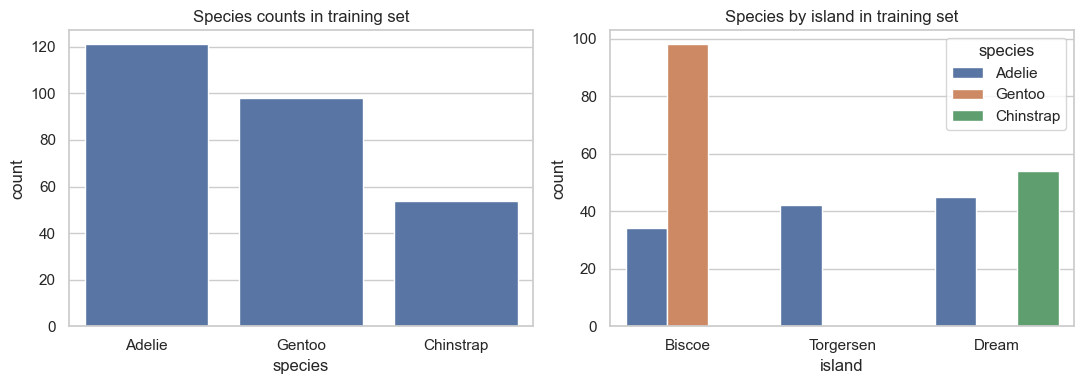

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(data=penguins_train, x="species", ax=axes[0])
axes[0].set_title("Species counts in training set")
axes[0].set_xlabel("species")
axes[0].set_ylabel("count")

sns.countplot(data=penguins_train, x="island", hue="species", ax=axes[1])
axes[1].set_title("Species by island in training set")
axes[1].set_xlabel("island")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

회귀 모델이 예측해야 하는 타깃은 `body_mass_g`이다. 몸무게의 전체 분포를 히스토그램으로 확인하고, 종에 따라 몸무게 분포가 어떻게 다른지 상자그림으로 비교한다. 종별 차이가 크다면 앞선 분할에서 종 비율을 유지한 이유도 이해할 수 있다.

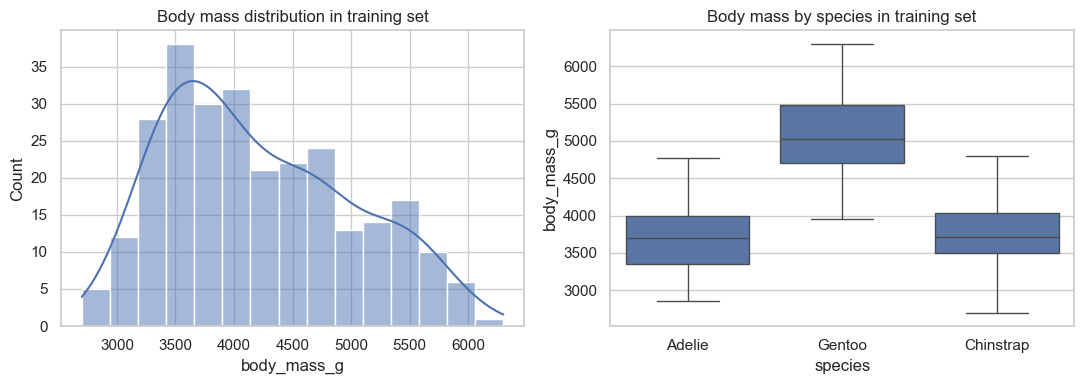

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(data=penguins_train, x="body_mass_g", bins=15, kde=True, ax=axes[0])
axes[0].set_title("Body mass distribution in training set")

sns.boxplot(data=penguins_train, x="species", y="body_mass_g", ax=axes[1])
axes[1].set_title("Body mass by species in training set")

plt.tight_layout()
plt.show()

입력 후보인 세 가지 신체 측정값의 종별 분포를 상자그림으로 비교한다. 상자그림은 값의 중심과 퍼짐을 보여 주므로, 종에 따라 신체 측정값이 어떻게 달라지는지 확인할 수 있다.

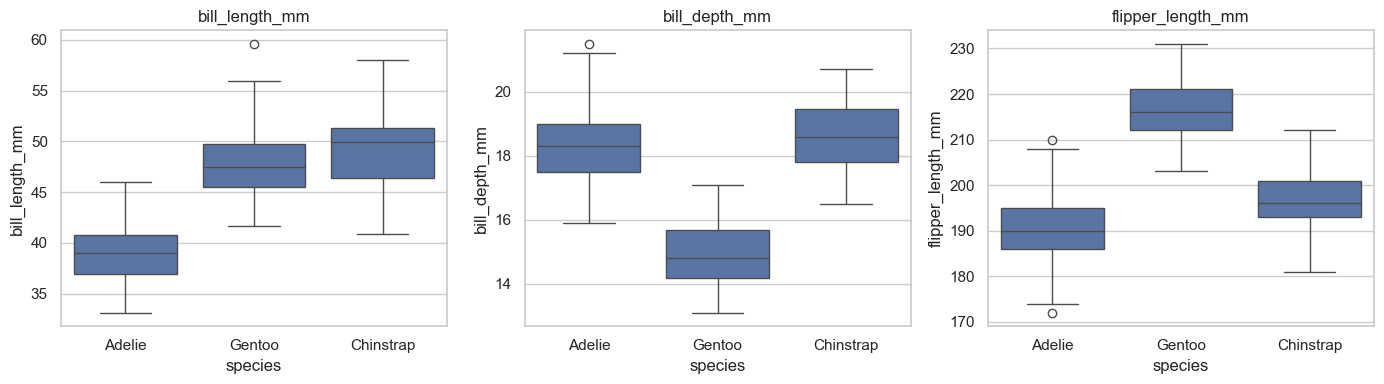

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for feature, ax in zip(regression_features, axes):
    sns.boxplot(data=penguins_train, x="species", y=feature, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("species")

plt.tight_layout()
plt.show()

**신체 측정값과 몸무게의 관계**

세 가지 입력 특성과 몸무게의 관계를 산점도로 살펴본다. 점의 색은 종을 나타내며, 각 측정값이 증가할 때 몸무게도 함께 증가하는 경향이 있는지 확인한다.

산점도에서 점들이 오른쪽 위 방향으로 모이면 해당 입력 특성이 큰 펭귄일수록 몸무게도 큰 경향이 있다는 뜻이다. 다만 산점도에서 보이는 관계는 예측에 활용할 단서이지, 한 특성이 몸무게를 직접 결정한다는 인과관계를 의미하지는 않는다.

종을 색으로 구분하면, 전체적인 관계와 함께 종마다 점들의 위치가 달라지는지도 관찰할 수 있다. 이 차이는 `species`를 기준으로 층화 분할한 이유와도 연결된다.

이 장에서는 세 신체 측정값을 모두 입력 후보로 사용하여 첫 회귀 모델을 만든다. 이후 연습문제에서 특성을 줄였을 때 평가 결과가 어떻게 달라지는지 비교할 수 있다.

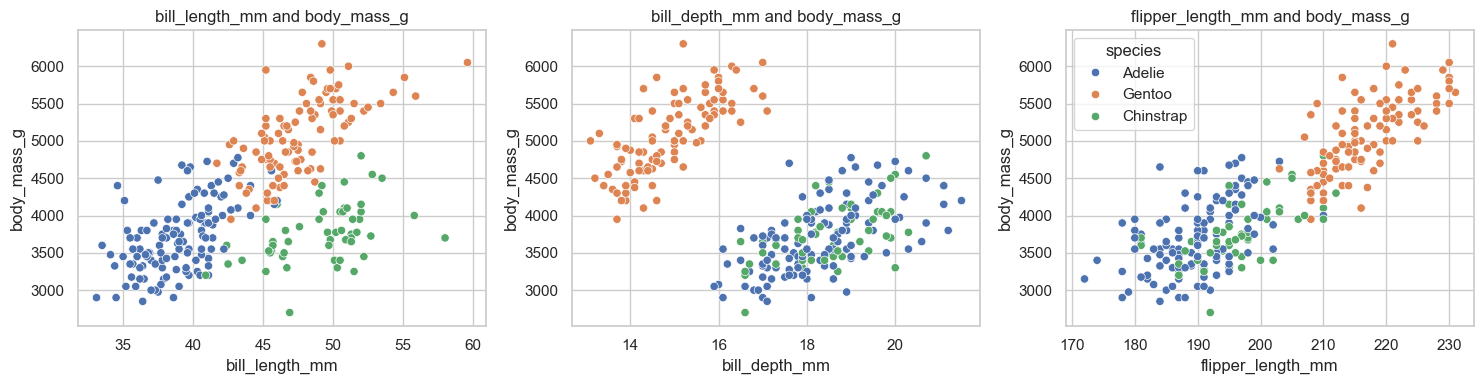

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for feature, ax in zip(regression_features, axes):
    sns.scatterplot(
        data=penguins_train,
        x=feature,
        y=target,
        hue="species",
        ax=ax,
        legend=(feature == regression_features[-1]),
    )
    ax.set_title(f"{feature} and {target}")

plt.tight_layout()
plt.show()

수치형 특성 사이의 상관계수를 계산하고 히트맵으로 시각화한다. 여기서는 모델에 사용하지 않는 `year`를 제외하고, 입력 특성 세 개와 타깃 `body_mass_g`만 비교한다. 상관계수는 두 변수가 함께 변하는 경향을 요약하며, 인과관계를 뜻하지는 않는다.

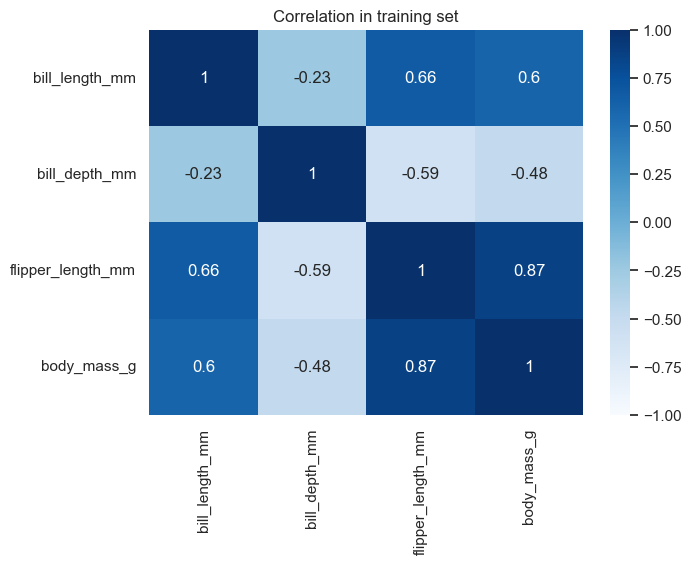

In [21]:
correlation_columns = regression_features + [target]
corr = penguins_train[correlation_columns].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="Blues", vmin=-1, vmax=1)
plt.title("Correlation in training set")
plt.show()

타깃인 몸무게와 각 입력 특성의 상관계수를 값으로도 확인한다. 절댓값이 클수록 두 값이 함께 변하는 경향이 더 뚜렷하며, 양수이면 한 값이 증가할 때 다른 값도 증가하는 경향을 뜻한다.

In [22]:
corr[target].drop(target).sort_values(ascending=False)

flipper_length_mm    0.866949
bill_length_mm       0.597523
bill_depth_mm       -0.479623
Name: body_mass_g, dtype: float64

마지막으로 모델에 사용할 세 입력 특성과 타깃의 기본 통계량을 훈련셋에서 확인한다. 평균, 사분위수, 최솟값과 최댓값은 모델이 학습할 값의 범위를 이해하는 데 도움을 준다.

In [23]:
penguins_train[correlation_columns].describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,273.000000,273.000000,273.000000,273.000000
mean,44.071795,17.134799,200.948718,4209.798535
std,5.496146,2.008492,13.907954,800.084816
min,33.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.300000,190.000000,3550.000000
50%,44.900000,17.300000,197.000000,4050.000000
75%,48.700000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


## 6단계: 회귀 모델 훈련

훈련셋을 이용한 EDA에서 종에 따라 몸무게 분포가 다르고, 특히 날개 길이를 포함한 신체 측정값이 몸무게와 관련되어 있음을 확인했다. 이제 세 가지 신체 측정값을 이용해 **몸무게를 예측하는 회귀 문제**를 다룬다.

- **입력 특성과 타깃 정하기**: `body_mass_g`를 타깃으로 둔다. 타깃으로 사용할 열은 입력 특성에서 제외하여 모델이 정답을 그대로 보지 않도록 한다.

- **훈련셋과 테스트셋 유지하기**: 앞에서 분리한 훈련셋으로만 모델을 학습시키고, 테스트셋은 마지막 일반화 성능 평가에 사용한다.

이제 준비된 훈련셋을 사용하여 펭귄 몸무게를 예측하는 선형 회귀 모델을 훈련한다.


**회귀: 펭귄 몸무게 예측**
 
이번 문제는 펭귄의 신체 측정값을 이용하여 몸무게를 예측하는 **회귀**이다.
 
 - 입력 특성: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`
 - 타깃: `body_mass_g`
 - 모델: 선형 회귀
 
분류가 범주를 예측하는 문제라면, 회귀는 연속적인 수치를 예측하는 문제이다.

회귀 문제에 사용할 입력 특성과 타깃을 정한다. 여기서는 몸무게를 예측해야 하므로 `body_mass_g`를 타깃으로 두고, 앞서 탐색한 세 신체 측정값을 입력으로 사용한다.

In [24]:
X_reg_train = penguins_train[regression_features]
y_reg_train = penguins_train[target]

X_reg_test = penguins_test[regression_features]
y_reg_test = penguins_test[target]

X_reg_train.shape, X_reg_test.shape

((273, 3), (69, 3))

선형 회귀 모델을 훈련하기 전에 수치형 특성을 표준화한다. 훈련셋에서 계산한 평균과 표준편차를 테스트셋에도 그대로 적용해야 테스트셋 정보가 훈련 과정에 섞이지 않는다.

In [25]:
reg_scaler = StandardScaler()

X_reg_train_scaled = pd.DataFrame(
    reg_scaler.fit_transform(X_reg_train),
    columns=regression_features,
    index=X_reg_train.index,
)
X_reg_test_scaled = pd.DataFrame(
    reg_scaler.transform(X_reg_test),
    columns=regression_features,
    index=X_reg_test.index,
)

In [26]:
reg_model = LinearRegression()
reg_model.fit(X_reg_train_scaled, y_reg_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 7단계: 훈련 결과 해석

선형 회귀 모델은 표준화된 신체 측정값과 몸무게 사이의 관계를 학습한다. 학습이 완료되면 모델이 단순히 훈련 데이터를 기억한 것이 아니라, 새로운 데이터에서도 유용한 예측을 할 수 있는지 평가해야 한다.

따라서 훈련에 사용하지 않은 테스트셋에 모델을 적용하여 실제 몸무게와 예측 몸무게를 비교한다. 이 비교를 통해 예측 오차의 크기와 모델이 몸무게 변동을 얼마나 설명하는지 해석할 수 있다.

## 8단계: 일반화 성능 평가

훈련된 모델의 **일반화 성능**은 훈련 과정에서 사용하지 않은 테스트셋에 대해 얼마나 정확하게 예측하는지를 의미한다. 훈련셋에서 성능이 좋아도 테스트셋에서 오차가 크다면 새로운 데이터에 잘 적용된다고 보기 어렵다.

테스트셋의 몸무게를 예측하고 MAE, RMSE, R2 점수를 계산한다. 여러 평가 지표를 함께 보면 오차의 평균적인 크기와 모델의 설명력을 동시에 판단할 수 있다.

In [27]:
y_reg_pred = reg_model.predict(X_reg_test_scaled)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

pd.DataFrame(
    {
        "metric": ["MAE", "RMSE", "R2"],
        "value": [mae, rmse, r2],
    }
)

,metric,value
0,MAE,294.212399
1,RMSE,369.406925
2,R2,0.791238


실제 몸무게와 예측 몸무게를 하나의 데이터프레임으로 정리한다. 몇 개의 예측 결과를 직접 비교하면 평가 지표만 볼 때보다 모델의 예측 수준을 더 구체적으로 이해할 수 있다.

In [28]:
results = pd.DataFrame({
    "actual": y_reg_test,
    "predicted": y_reg_pred,
})

results.head(10)

,actual,predicted
151,4000.0,4225.231874
1,3800.0,3444.967491
226,4700.0,4939.956363
268,4875.0,4994.587222
282,3250.0,3081.507938
103,4250.0,3682.899429
303,3800.0,4214.129824
237,5600.0,5598.644572
304,3700.0,3729.640650
297,3400.0,3732.732587


실제값과 예측값을 산점도로 비교한다. 빨간 점선은 실제값과 예측값이 완전히 같은 경우를 나타내며, 점들이 이 선에 가까울수록 예측이 잘 된 것이다.

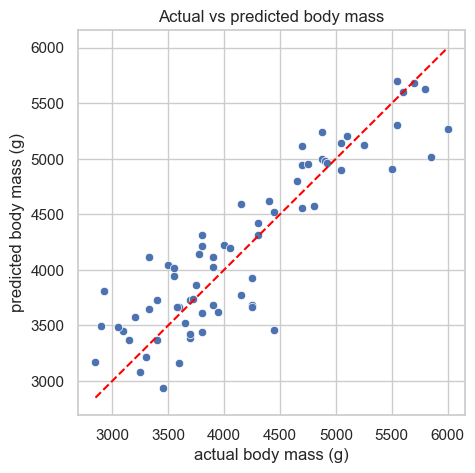

In [29]:
plt.figure(figsize=(5, 5))
sns.scatterplot(data=results, x="actual", y="predicted")

min_value = min(results["actual"].min(), results["predicted"].min())
max_value = max(results["actual"].max(), results["predicted"].max())
plt.plot([min_value, max_value], [min_value, max_value], color="red", linestyle="--")

plt.title("Actual vs predicted body mass")
plt.xlabel("actual body mass (g)")
plt.ylabel("predicted body mass (g)")
plt.show()

MAE는 예측값이 실제값에서 평균적으로 얼마나 벗어났는지를 그램 단위로 보여준다. RMSE는 큰 오차에 더 민감한 지표이다. R2 점수는 입력 특성이 타깃의 변동을 어느 정도 설명하는지 나타내며, 1에 가까울수록 좋다.

## 정리

이번 장에서는 펭귄 몸무게 예측 문제를 통해 회귀 모델의 기본 흐름을 살펴보았다.

- 회귀는 연속적인 수치를 예측하는 문제이다.
- 훈련셋과 테스트셋을 나누어 모델이 처음 보는 데이터에서도 잘 작동하는지 확인한다.
- MAE, RMSE, R2는 회귀 모델의 성능을 서로 다른 관점에서 보여준다.
- 실제값과 예측값을 산점도로 비교하면 모델의 예측 수준을 직관적으로 볼 수 있다.

여기서는 회귀의 전체 흐름을 단순하게 보기 위해 작은 펭귄 데이터셋을 사용했다. 더 복잡한 회귀 문제에서는 더 많은 특성, 범주형 변수 처리, 특성 선택, 모델 비교 등이 함께 필요할 수 있다.

## 연습문제

**문제 1**

`bill_length_mm`, `bill_depth_mm`만 사용하여 몸무게를 예측해 보아라. 세 특성을 모두 사용했을 때와 성능이 어떻게 달라지는가?

**문제 2**

`flipper_length_mm` 하나만 사용하여 몸무게를 예측해 보아라. 산점도에서 보았던 관계가 회귀 성능에도 반영되는가?

**문제 3**

훈련셋과 테스트셋을 나눌 때 `stratify` 옵션을 제거해 보아라. 평가 결과가 달라지는지 확인해 보아라.